In [1]:
import os
import pickle
import xml.etree.ElementTree as ET
from lxml import etree
import redis
import sqlite3
import duckdb
import psycopg2
from pymongo import MongoClient

import random
from tqdm import tqdm
from datetime import datetime
from faker import Faker

import pandas as pd
import matplotlib.pyplot as plt


first_run= False
use_xml_backup = True

if first_run and use_xml_backup:
    print("⚠️\tYou must not set first_run and use_xml_backup to 'True' at the same time.\n\tThe XML backup will be created at the first run.\n")

verbose=True

pg_host="localhost"
pg_port=5432
pg_database="david"
pg_user="david"
pg_password="david"

stats={'db':[],
            }
stats['db'].append('xml')
stats['db'].append('lxml')
stats['db'].append('redis')
stats['db'].append('sqlite3')
stats['db'].append('duckdb')
stats['db'].append('postgres')
stats['db'].append('mongodb')
stats['db'].append('mongodb (idx)')


experimental_runs=[
    1,
    10,
    100,
    1000,
    10000,
    100000,
    200000,
    500000,
]

for experiment in experimental_runs:
    stats[experiment]=[]

init_times={'db':[],
            'duration':[]
            }
init_times['db'].append('xml')
init_times['db'].append('lxml')
init_times['db'].append('redis')
init_times['db'].append('sqlite3')
init_times['db'].append('duckdb')
init_times['db'].append('postgres')
init_times['db'].append('mongodb')
init_times['db'].append('mongodb (idx)')


# generate fake data (only relevant for RDBMS)
fake = Faker()

fake_k=100000
fake_numbers = random.sample(range(100_000_000, 1_000_000_000), k=fake_k)
fake_ppns=["PPx"+str(x) for x in fake_numbers]
fake_titles=[fake.sentence() for _ in range(fake_k)]


startTime = datetime.now()
xmlPath="../data/xml/sample/__metsmods/PPN745182844.xml"

tree = ET.parse(xmlPath)
root = tree.getroot()


# max index, i.e., the last "page"
maxIndex=1
# we are only interested in fileGrp nodes below fileSec...
for fileSec in root.iter("{http://www.loc.gov/METS/}fileSec"):
    for child in fileSec.iter("{http://www.loc.gov/METS/}fileGrp"):
        currentUse = child.attrib["USE"]

        firstFileNode = True
        if currentUse== "PRESENTATION":
            # which contains file nodes...
            for fileNode in child.iter("{http://www.loc.gov/METS/}file"):
                # embedding FLocat node pointing to the URLs of interest
                id = fileNode.attrib["ID"]
                currentIndex=int(id.split("_")[1])
                maxIndex =  currentIndex
                #print(f"\thref: {str(fileNode[0].attrib["{http://www.w3.org/1999/xlink}href"])}")

endTime = datetime.now()
duration = endTime - startTime

init_xml=duration.total_seconds()
init_times['duration'].append(init_xml)

print(f"Duration:\t{str(duration)}")
print("\nStarted at:\t%s\nEnded at:\t%s" % (startTime, endTime))
print(f"Max index:\t{maxIndex}")

Duration:	0:00:00.006918

Started at:	2026-05-14 12:35:38.018799
Ended at:	2026-05-14 12:35:38.025717
Max index:	341


## XML

__ATTENTION:__ Do not move this block otherwise the XML backup mechanism will not work. Only add other DBs after the LXML block.

In [2]:
def getPageFromXML(index):
    xmlPath="../data/xml/sample/__metsmods/PPN745182844.xml"

    tree = ET.parse(xmlPath)
    root = tree.getroot()
    for fileSec in root.iter("{http://www.loc.gov/METS/}fileSec"):
        for child in fileSec.iter("{http://www.loc.gov/METS/}fileGrp"):
            currentUse = child.attrib["USE"]

            firstFileNode = True
            if currentUse== "PRESENTATION":
                # which contains file nodes...
                for fileNode in child.iter("{http://www.loc.gov/METS/}file"):
                    # embedding FLocat node pointing to the URLs of interest
                    id = fileNode.attrib["ID"]
                    currentIndex=int(id.split("_")[1])
                    if currentIndex==index:
                        # returns the href to the presentation index
                        return str(fileNode[0].attrib["{http://www.w3.org/1999/xlink}href"])

In [3]:
if not use_xml_backup or first_run:
    for experiment in experimental_runs:
        startTime = datetime.now()
        for i in tqdm(range(experiment)):
            selectedPage=random.randint(1, maxIndex)
            returnedHref=getPageFromXML(selectedPage)
        endTime = datetime.now()

        duration = endTime - startTime
        stats[experiment].append(duration.total_seconds())

        print("%i runs\nStarted at:\t%s\nEnded at:\t%s" % (experiment,startTime, endTime))
        print(f"Duration:\t{str(duration)}\n")
else:
    print("Restoring from XML backup.")
    stats=pickle.load(open("../data/stats_after_xml.pickle", "rb"))

expected_len=stats['db'].index('xml')+1
if expected_len != len(stats[1]):
    display(stats)
    print("⚠️\tExpected array size invalid! Did you run one or more cells repeatedly?\n\tYou will have to restart the notebook.")

Restoring from XML backup.


In [4]:
# as the XML processing takes quite a while we will make a backup to continue from this cell on the first run.
if first_run:
    pickle.dump(stats, open("../data/stats_after_xml.pickle", "wb"))
    print("Saved XML backup.")

## LXML

__ATTENTION:__ Do not move this block otherwise the XML backup mechanism will not work. Only add other DBs after the LXML block.

In [5]:
def getPageFromLXML(index):
    xmlPath="../data/xml/sample/__metsmods/PPN745182844.xml"

    tree = etree.parse(xmlPath)
    root = tree.getroot()
    for fileSec in root.iter("{http://www.loc.gov/METS/}fileSec"):
        for child in fileSec.iter("{http://www.loc.gov/METS/}fileGrp"):
            currentUse = child.attrib["USE"]

            firstFileNode = True
            if currentUse== "PRESENTATION":
                # which contains file nodes...
                for fileNode in child.iter("{http://www.loc.gov/METS/}file"):
                    # embedding FLocat node pointing to the URLs of interest
                    id = fileNode.attrib["ID"]
                    currentIndex=int(id.split("_")[1])
                    if currentIndex==index:
                        # returns the href to the presentation index
                        return str(fileNode[0].attrib["{http://www.w3.org/1999/xlink}href"])

if not use_xml_backup or first_run:
    for experiment in experimental_runs:
        startTime = datetime.now()
        for i in tqdm(range(experiment)):
            selectedPage=random.randint(1, maxIndex)
            returnedHref=getPageFromLXML(selectedPage)
        endTime = datetime.now()

        duration = endTime - startTime
        stats[experiment].append(duration.total_seconds())

        print("%i runs\nStarted at:\t%s\nEnded at:\t%s" % (experiment,startTime, endTime))
        print(f"Duration:\t{str(duration)}\n")
else:
    print("Restoring from XML backup.")
    stats=pickle.load(open("../data/stats_after_lxml.pickle", "rb"))
# dummy init time
init_times['duration'].append(init_xml)

expected_len=stats['db'].index('lxml')+1
if expected_len != len(stats[1]):
    display(stats)
    print("⚠️\tExpected array size invalid! Did you run one or more cells repeatedly?\n\tYou will have to restart the notebook.")

Restoring from XML backup.


In [6]:
# as the XML processing takes quite a while we will make a backup to continue from this cell on the first run.
if first_run:
    pickle.dump(stats, open("../data/stats_after_lxml.pickle", "wb"))
    print("Saved XML backup (for LXML run).")

## Redis


In [7]:
startTime = datetime.now()
r = redis.Redis(host='localhost', port=6379, decode_responses=True)
r.flushall()

tree = ET.parse(xmlPath)
root = tree.getroot()

# max index, i.e., the last "page"
maxIndex=1
# we are only interested in fileGrp nodes below fileSec...
for fileSec in root.iter("{http://www.loc.gov/METS/}fileSec"):
    for child in fileSec.iter("{http://www.loc.gov/METS/}fileGrp"):
        currentUse = child.attrib["USE"]

        firstFileNode = True
        if currentUse== "PRESENTATION":
            # which contains file nodes...
            for fileNode in child.iter("{http://www.loc.gov/METS/}file"):
                # embedding FLocat node pointing to the URLs of interest
                id = fileNode.attrib["ID"]
                currentIndex=int(id.split("_")[1])
                maxIndex =  currentIndex
                r.set(currentIndex,str(fileNode[0].attrib["{http://www.w3.org/1999/xlink}href"]))
endTime = datetime.now()
duration = endTime - startTime
init_redis=duration.total_seconds()
init_times['duration'].append(init_redis)

In [8]:
for experiment in experimental_runs:
    startTime = datetime.now()
    for i in tqdm(range(experiment)):
        selectedPage=random.randint(1, maxIndex)
        returnedHref=r.get(selectedPage)

    endTime = datetime.now()
    duration = endTime - startTime
    stats[experiment].append(duration.total_seconds())

    print("%i runs\nStarted at:\t%s\nEnded at:\t%s\n" % (experiment,startTime, endTime))
    print(f"Duration:\t{str(duration)}\n")

r.close()

expected_len=stats['db'].index('redis')+1
if expected_len != len(stats[1]):
    display(stats)
    print("⚠️\tExpected array size invalid! Did you run one or more cells repeatedly?\n\tYou will have to restart the notebook.")

100%|██████████| 1/1 [00:00<00:00, 1253.53it/s]


1 runs
Started at:	2026-05-14 12:35:38.266794
Ended at:	2026-05-14 12:35:38.286902

Duration:	0:00:00.020108



100%|██████████| 10/10 [00:00<00:00, 4166.39it/s]


10 runs
Started at:	2026-05-14 12:35:38.286940
Ended at:	2026-05-14 12:35:38.290886

Duration:	0:00:00.003946



100%|██████████| 100/100 [00:00<00:00, 10280.66it/s]


...

100000 runs
Started at:	2026-05-14 12:35:38.865033
Ended at:	2026-05-14 12:35:43.758429

Duration:	0:00:04.893396



100%|██████████| 200000/200000 [00:09<00:00, 21043.12it/s]


200000 runs
Started at:	2026-05-14 12:35:43.758460
Ended at:	2026-05-14 12:35:53.263662

Duration:	0:00:09.505202



100%|██████████| 500000/500000 [00:22<00:00, 22123.08it/s]

500000 runs
Started at:	2026-05-14 12:35:53.263684
Ended at:	2026-05-14 12:36:15.865601

Duration:	0:00:22.601917



## SQLite

In [9]:
startTime = datetime.now()

tree = ET.parse(xmlPath)
root = tree.getroot()

con = sqlite3.connect("../data/sqlite/htw.db")
cur = con.cursor()

cur.execute("DROP TABLE IF EXISTS media;")
cur.execute("CREATE TABLE media (ppn PRIMARY KEY, dummy_data NOT NULL);")

cur.execute("DROP TABLE IF EXISTS documents;")
cur.execute("CREATE TABLE documents (ppn NOT NULL, page NOT NULL, href NOT NULL,  FOREIGN KEY (ppn) REFERENCES media);")

sample_ppn = "PPN745182844"
dummy_text = "Title"
cur.execute("INSERT INTO media VALUES (?, ?);", (sample_ppn,dummy_text))

# add fake documents:
for i in range(fake_k):
    cur.execute("INSERT INTO media VALUES (?, ?);", (fake_ppns[i],fake_titles[i]))

# we are only interested in fileGrp nodes below fileSec...
for fileSec in root.iter("{http://www.loc.gov/METS/}fileSec"):
    for child in fileSec.iter("{http://www.loc.gov/METS/}fileGrp"):
        currentUse = child.attrib["USE"]

        firstFileNode = True
        if currentUse== "PRESENTATION":
            # which contains file nodes...
            for fileNode in child.iter("{http://www.loc.gov/METS/}file"):
                # embedding FLocat node pointing to the URLs of interest
                id = fileNode.attrib["ID"]
                currentIndex=int(id.split("_")[1])
                maxIndex =  currentIndex
                cur.execute("INSERT INTO documents VALUES('"+sample_ppn+"',"+str(currentIndex)+",'"+str(fileNode[0].attrib["{http://www.w3.org/1999/xlink}href"])+"');")

cur.close()
con.commit()
con.close()

endTime = datetime.now()
duration = endTime - startTime
init_sqlite=duration.total_seconds()

init_times['duration'].append(init_sqlite)

In [10]:
con = sqlite3.connect("../data/sqlite/htw.db")
cur = con.cursor()

for experiment in experimental_runs:
    startTime = datetime.now()
    print(experiment)

    for i in tqdm(range(experiment)):
        selectedPage=random.randint(1, maxIndex)
        #print("SELECT * FROM documents WHERE page="+str(selectedPage)+";")
        #sql_cmd="SELECT * FROM documents WHERE page="+str(selectedPage)+";"
        sql_cmd="SELECT href FROM documents JOIN media ON documents.ppn=media.ppn WHERE page="+str(selectedPage)+";"
        returnedHref=cur.execute(sql_cmd).fetchone()

    endTime = datetime.now()
    duration = endTime - startTime
    stats[experiment].append(duration.total_seconds())

    print("%i runs\nStarted at:\t%s\nEnded at:\t%s\n" % (experiment,startTime, endTime))
    print(f"Duration:\t{str(duration)}\n")

cur.close()
con.close()

expected_len=stats['db'].index('sqlite3')+1
if expected_len != len(stats[1]):
    display(stats)
    print("⚠️\tExpected array size invalid! Did you run one or more cells repeatedly?\n\tYou will have to restart the notebook.")

1


100%|██████████| 1/1 [00:00<00:00, 2362.99it/s]


1 runs
Started at:	2026-05-14 12:36:16.110039
Ended at:	2026-05-14 12:36:16.111542

Duration:	0:00:00.001503

10


100%|██████████| 10/10 [00:00<00:00, 7241.55it/s]


10 runs
Started at:	2026-05-14 12:36:16.111571
Ended at:	2026-05-14 12:36:16.114140

Duration:	0:00:00.002569

100


...

100000 runs
Started at:	2026-05-14 12:36:16.336975
Ended at:	2026-05-14 12:36:18.238904

Duration:	0:00:01.901929

200000


100%|██████████| 200000/200000 [00:03<00:00, 52811.00it/s]


200000 runs
Started at:	2026-05-14 12:36:18.238931
Ended at:	2026-05-14 12:36:22.026949

Duration:	0:00:03.788018

500000


100%|██████████| 500000/500000 [00:09<00:00, 52615.09it/s]

500000 runs
Started at:	2026-05-14 12:36:22.026977
Ended at:	2026-05-14 12:36:31.530944

Duration:	0:00:09.503967



## DuckDB

In [11]:
startTime = datetime.now()

tree = ET.parse(xmlPath)
root = tree.getroot()

duckdb.close()
duckdb.sql("DROP TABLE IF EXISTS media CASCADE;")
duckdb.sql("CREATE TABLE media (ppn VARCHAR(12) PRIMARY KEY, dummy_data VARCHAR (50) NOT NULL);")

duckdb.sql("DROP TABLE IF EXISTS documents CASCADE;")
duckdb.sql("CREATE TABLE documents (ppn VARCHAR(12) NOT NULL, page INT NOT NULL, href VARCHAR(200) NOT NULL,  FOREIGN KEY (ppn) REFERENCES media);")

sample_ppn = "PPN745182844"
dummy_text = "Title"
duckdb.sql("INSERT INTO media VALUES (?, ?)", params=[sample_ppn,dummy_text])

for i in range(fake_k):
    duckdb.sql("INSERT INTO media VALUES (?, ?);", params=[fake_ppns[i],fake_titles[i]])

# we are only interested in fileGrp nodes below fileSec...
for fileSec in root.iter("{http://www.loc.gov/METS/}fileSec"):
    for child in fileSec.iter("{http://www.loc.gov/METS/}fileGrp"):
        currentUse = child.attrib["USE"]

        firstFileNode = True
        if currentUse== "PRESENTATION":
            # which contains file nodes...
            for fileNode in child.iter("{http://www.loc.gov/METS/}file"):
                # embedding FLocat node pointing to the URLs of interest
                id = fileNode.attrib["ID"]
                currentIndex=int(id.split("_")[1])
                maxIndex =  currentIndex
                duckdb.sql("INSERT INTO documents VALUES('"+sample_ppn+"',"+str(currentIndex)+",'"+str(fileNode[0].attrib["{http://www.w3.org/1999/xlink}href"])+"');")

endTime = datetime.now()
duration = endTime - startTime
init_duckdb=duration.total_seconds()

init_times['duration'].append(init_duckdb)


In [12]:
for experiment in experimental_runs:
    startTime = datetime.now()
    print(experiment)

    for i in tqdm(range(experiment)):
        selectedPage=random.randint(1, maxIndex)
        #print("SELECT * FROM documents WHERE page="+str(selectedPage)+";")
        #sql_cmd="SELECT * FROM documents WHERE page="+str(selectedPage)+";"
        sql_cmd="SELECT href FROM documents JOIN media ON documents.ppn=media.ppn WHERE page=?;"

        returnedHref=duckdb.sql(sql_cmd,params=[selectedPage]).fetchone()



    endTime = datetime.now()
    duration = endTime - startTime
    stats[experiment].append(duration.total_seconds())
    print("apend")

    print("%i runs\nStarted at:\t%s\nEnded at:\t%s\n" % (experiment,startTime, endTime))
    print(f"Duration:\t{str(duration)}\n")

duckdb.close() # closes and deletes the in-memory db

expected_len=stats['db'].index('duckdb')+1
if expected_len != len(stats[1]):
    display(stats)
    print("⚠️\tExpected array size invalid! Did you run one or more cells repeatedly?\n\tYou will have to restart the notebook.")

1


100%|██████████| 1/1 [00:00<00:00, 793.62it/s]


apend
1 runs
Started at:	2026-05-14 12:36:46.136144
Ended at:	2026-05-14 12:36:46.138943

Duration:	0:00:00.002799

10


100%|██████████| 10/10 [00:00<00:00, 2240.07it/s]


apend
10 runs
Started at:	2026-05-14 12:36:46.138985
Ended at:	2026-05-14 12:36:46.144558

Duration:	0:00:00.005573

100


...

apend
100000 runs
Started at:	2026-05-14 12:36:49.474989
Ended at:	2026-05-14 12:37:18.639232

Duration:	0:00:29.164243

200000


100%|██████████| 200000/200000 [00:58<00:00, 3417.92it/s]


apend
200000 runs
Started at:	2026-05-14 12:37:18.639261
Ended at:	2026-05-14 12:38:17.155352

Duration:	0:00:58.516091

500000


100%|██████████| 500000/500000 [02:27<00:00, 3392.94it/s]

apend
500000 runs
Started at:	2026-05-14 12:38:17.155387
Ended at:	2026-05-14 12:40:44.521290

Duration:	0:02:27.365903



## PostgreSQL

In [13]:
startTime = datetime.now()

con = psycopg2.connect(
    host=pg_host,
    port=pg_port,
    database=pg_database,
    user=pg_user,
    password=pg_password
)

cur = con.cursor()

tree = ET.parse(xmlPath)
root = tree.getroot()



cur.execute("DROP TABLE IF EXISTS media CASCADE;")
cur.execute("CREATE TABLE media (ppn VARCHAR(12) PRIMARY KEY, dummy_data VARCHAR (200) NOT NULL);")

cur.execute("DROP TABLE IF EXISTS documents;")
cur.execute("CREATE TABLE documents (ppn VARCHAR(12) NOT NULL, page INT NOT NULL, href VARCHAR(200) NOT NULL,  FOREIGN KEY (ppn) REFERENCES media);")

sample_ppn = "PPN745182844"
dummy_text = "Title"
sql_cmd="""INSERT INTO media VALUES(%s,%s);"""
cur.execute(sql_cmd, (sample_ppn,dummy_text))

# add fake documents:
for i in range(fake_k):
    cur.execute(sql_cmd, (fake_ppns[i],fake_titles[i]))

# we are only interested in fileGrp nodes below fileSec...
for fileSec in root.iter("{http://www.loc.gov/METS/}fileSec"):
    for child in fileSec.iter("{http://www.loc.gov/METS/}fileGrp"):
        currentUse = child.attrib["USE"]

        firstFileNode = True
        if currentUse== "PRESENTATION":
            # which contains file nodes...
            for fileNode in child.iter("{http://www.loc.gov/METS/}file"):
                # embedding FLocat node pointing to the URLs of interest
                id = fileNode.attrib["ID"]
                currentIndex=int(id.split("_")[1])
                maxIndex =  currentIndex
                cur.execute("INSERT INTO documents VALUES('"+sample_ppn+"',"+str(currentIndex)+",'"+str(fileNode[0].attrib["{http://www.w3.org/1999/xlink}href"])+"');")

cur.close()
con.commit()
con.close()

endTime = datetime.now()
duration = endTime - startTime
init_postgres=duration.total_seconds()

init_times['duration'].append(init_postgres)

In [14]:
con = psycopg2.connect(
    host=pg_host,
    port=pg_port,
    database=pg_database,
    user=pg_user,
    password=pg_password
)


cur = con.cursor()

for experiment in experimental_runs:
    startTime = datetime.now()
    print(experiment)

    for i in tqdm(range(experiment)):
        selectedPage=random.randint(1, maxIndex)
        #print("SELECT * FROM documents WHERE page="+str(selectedPage)+";")
        #sql_cmd="SELECT * FROM documents WHERE page="+str(selectedPage)+";"
        sql_cmd="""SELECT href FROM documents JOIN media ON documents.ppn=media.ppn WHERE page=%s;"""
        try:
            cur.execute(sql_cmd,(selectedPage,))
            returnedHref=cur.fetchone()
        except psycopg2.Error as e:
            print(f"An error occurred: {e.pgcode} - {e.pgerror}")

    endTime = datetime.now()
    duration = endTime - startTime
    stats[experiment].append(duration.total_seconds())
    print("apend")

    print("%i runs\nStarted at:\t%s\nEnded at:\t%s\n" % (experiment,startTime, endTime))
    print(f"Duration:\t{str(duration)}\n")

cur.close()
con.close()

expected_len=stats['db'].index('postgres')+1
if expected_len != len(stats[1]):
    display(stats)
    print("⚠️\tExpected array size invalid! Did you run one or more cells repeatedly?\n\tYou will have to restart the notebook.")

1


100%|██████████| 1/1 [00:00<00:00, 774.00it/s]


apend
1 runs
Started at:	2026-05-14 12:40:48.813861
Ended at:	2026-05-14 12:40:48.817177

Duration:	0:00:00.003316

10


100%|██████████| 10/10 [00:00<00:00, 7003.35it/s]


apend
10 runs
Started at:	2026-05-14 12:40:48.817216
Ended at:	2026-05-14 12:40:48.819625

Duration:	0:00:00.002409

100


...

apend
100000 runs
Started at:	2026-05-14 12:40:49.601970
Ended at:	2026-05-14 12:40:56.429585

Duration:	0:00:06.827615

200000


100%|██████████| 200000/200000 [00:13<00:00, 14646.38it/s]


apend
200000 runs
Started at:	2026-05-14 12:40:56.429613
Ended at:	2026-05-14 12:41:10.085898

Duration:	0:00:13.656285

500000


100%|██████████| 500000/500000 [00:36<00:00, 13885.18it/s]

apend
500000 runs
Started at:	2026-05-14 12:41:10.085926
Ended at:	2026-05-14 12:41:46.096779

Duration:	0:00:36.010853



## MongoDB


In [15]:
mongo_url="mongodb://localhost:27017"

startTime = datetime.now()

client = MongoClient(mongo_url)
client.drop_database("test_db")
database = client["test_db"]
database.create_collection("media")
collection = database["media"]


tree = ET.parse(xmlPath)
root = tree.getroot()

# max index, i.e., the last "page"
maxIndex=1
# we are only interested in fileGrp nodes below fileSec...
for fileSec in root.iter("{http://www.loc.gov/METS/}fileSec"):
    for child in fileSec.iter("{http://www.loc.gov/METS/}fileGrp"):
        currentUse = child.attrib["USE"]

        firstFileNode = True
        if currentUse== "PRESENTATION":
            # which contains file nodes...
            for fileNode in child.iter("{http://www.loc.gov/METS/}file"):
                # embedding FLocat node pointing to the URLs of interest
                id = fileNode.attrib["ID"]
                currentIndex=int(id.split("_")[1])
                maxIndex =  currentIndex
                collection.insert_one({ "page": currentIndex, "href" : str(fileNode[0].attrib["{http://www.w3.org/1999/xlink}href"]) })

endTime = datetime.now()
duration = endTime - startTime
init_mongo=duration.total_seconds()
init_times['duration'].append(init_mongo)



In [16]:
for experiment in experimental_runs:
    startTime = datetime.now()
    for i in tqdm(range(experiment)):
        selectedPage=random.randint(1, maxIndex)
        returnedHref=collection.find_one({ "page" : selectedPage})

    endTime = datetime.now()
    duration = endTime - startTime
    stats[experiment].append(duration.total_seconds())

    print("%i runs\nStarted at:\t%s\nEnded at:\t%s\n" % (experiment,startTime, endTime))
    print(f"Duration:\t{str(duration)}\n")

client.close()

expected_len=stats['db'].index('mongodb')+1
if expected_len != len(stats[1]):
    display(stats)
    print("⚠️\tExpected array size invalid! Did you run one or more cells repeatedly?\n\tYou will have to restart the notebook.")

100%|██████████| 1/1 [00:00<00:00, 869.47it/s]


1 runs
Started at:	2026-05-14 12:41:46.283800
Ended at:	2026-05-14 12:41:46.286233

Duration:	0:00:00.002433



100%|██████████| 10/10 [00:00<00:00, 2063.11it/s]


10 runs
Started at:	2026-05-14 12:41:46.286258
Ended at:	2026-05-14 12:41:46.292019

Duration:	0:00:00.005761



100%|██████████| 100/100 [00:00<00:00, 2103.98it/s]


...

100000 runs
Started at:	2026-05-14 12:41:49.935174
Ended at:	2026-05-14 12:42:28.496850

Duration:	0:00:38.561676



100%|██████████| 200000/200000 [01:18<00:00, 2541.89it/s]


200000 runs
Started at:	2026-05-14 12:42:28.496880
Ended at:	2026-05-14 12:43:47.179583

Duration:	0:01:18.682703



100%|██████████| 500000/500000 [03:24<00:00, 2441.04it/s]

500000 runs
Started at:	2026-05-14 12:43:47.179609
Ended at:	2026-05-14 12:47:12.011487

Duration:	0:03:24.831878



## MongoDB (Indexed)

In [17]:
mongo_url="mongodb://localhost:27017"

startTime = datetime.now()

client = MongoClient(mongo_url)
client.drop_database("test_db")
database = client["test_db"]
database.create_collection("media")
collection = database["media"]


tree = ET.parse(xmlPath)
root = tree.getroot()

# max index, i.e., the last "page"
maxIndex=1
# we are only interested in fileGrp nodes below fileSec...
for fileSec in root.iter("{http://www.loc.gov/METS/}fileSec"):
    for child in fileSec.iter("{http://www.loc.gov/METS/}fileGrp"):
        currentUse = child.attrib["USE"]

        firstFileNode = True
        if currentUse== "PRESENTATION":
            # which contains file nodes...
            for fileNode in child.iter("{http://www.loc.gov/METS/}file"):
                # embedding FLocat node pointing to the URLs of interest
                id = fileNode.attrib["ID"]
                currentIndex=int(id.split("_")[1])
                maxIndex =  currentIndex
                collection.insert_one({ "page": currentIndex, "href" : str(fileNode[0].attrib["{http://www.w3.org/1999/xlink}href"]) })

collection.create_index("page")

endTime = datetime.now()
duration = endTime - startTime
init_mongo=duration.total_seconds()
init_times['duration'].append(init_mongo)

In [18]:
for experiment in experimental_runs:
    startTime = datetime.now()
    for i in tqdm(range(experiment)):
        selectedPage=random.randint(1, maxIndex)
        returnedHref=collection.find_one({ "page" : selectedPage})

    endTime = datetime.now()
    duration = endTime - startTime
    stats[experiment].append(duration.total_seconds())

    print("%i runs\nStarted at:\t%s\nEnded at:\t%s\n" % (experiment,startTime, endTime))
    print(f"Duration:\t{str(duration)}\n")

client.close()

expected_len=stats['db'].index('mongodb (idx)')+1
if expected_len != len(stats[1]):
    display(stats)
    print("⚠️\tExpected array size invalid! Did you run one or more cells repeatedly?\n\tYou will have to restart the notebook.")

100%|██████████| 1/1 [00:00<00:00, 370.13it/s]


1 runs
Started at:	2026-05-14 12:47:12.189780
Ended at:	2026-05-14 12:47:12.194006

Duration:	0:00:00.004226



100%|██████████| 10/10 [00:00<00:00, 1423.92it/s]


10 runs
Started at:	2026-05-14 12:47:12.194033
Ended at:	2026-05-14 12:47:12.202148

Duration:	0:00:00.008115



100%|██████████| 100/100 [00:00<00:00, 1662.98it/s]


...

100000 runs
Started at:	2026-05-14 12:47:15.697109
Ended at:	2026-05-14 12:47:44.661549

Duration:	0:00:28.964440



100%|██████████| 200000/200000 [00:57<00:00, 3455.44it/s]


200000 runs
Started at:	2026-05-14 12:47:44.661571
Ended at:	2026-05-14 12:48:42.542395

Duration:	0:00:57.880824



100%|██████████| 500000/500000 [02:29<00:00, 3344.85it/s]

500000 runs
Started at:	2026-05-14 12:48:42.542419
Ended at:	2026-05-14 12:51:12.026858

Duration:	0:02:29.484439



## Analysis

In [19]:
if len(stats['db']) != len(stats[1]):
    print("⚠️\tExpected array size invalid! Did you run one or more cells repeatedly?\n\tYou will have to restart the notebook as the next call will crash soon.\n")

df = pd.DataFrame(stats)
df

,db,1,10,100,1000,10000,100000,200000,500000
0,xml,0.029430,0.111384,0.758837,7.657496,75.793651,759.285696,1521.204278,3852.393824
1,lxml,0.008119,0.046927,0.408921,3.792877,37.918528,378.940530,758.703098,1937.378222
2,redis,0.020108,0.003946,0.011603,0.060753,0.501682,4.893396,9.505202,22.601917
3,sqlite3,0.001503,0.002569,0.004071,0.023334,0.195252,1.901929,3.788018,9.503967
4,duckdb,0.002799,0.005573,0.040203,0.306369,2.983721,29.164243,58.516091,147.365903
5,postgres,0.003316,0.002409,0.010305,0.090423,0.681486,6.827615,13.656285,36.010853
6,mongodb,0.002433,0.005761,0.048637,0.336305,3.258112,38.561676,78.682703,204.831878
7,mongodb (idx),0.004226,0.008115,0.061813,0.440482,2.992562,28.964440,57.880824,149.484439


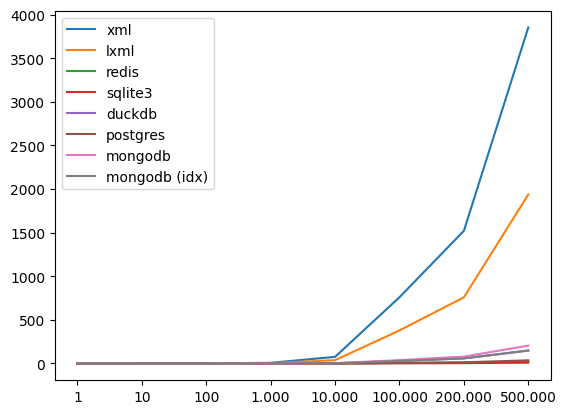

In [20]:
if not os.path.exists("../data/plots/"):
    os.makedirs("../data/plots/")

cols = [c for c in df.columns if c != 'db']

categories=[f"{x:,.0f}".replace(',', '.') for x in cols]

for _, row in df.iterrows():
    plt.plot(categories, row[cols], label=row['db'])
    #plt.plot(row[cols], cols, label=row['db'])

plt.legend()
plt.savefig('../data/plots/performance_all.pdf')
plt.show()

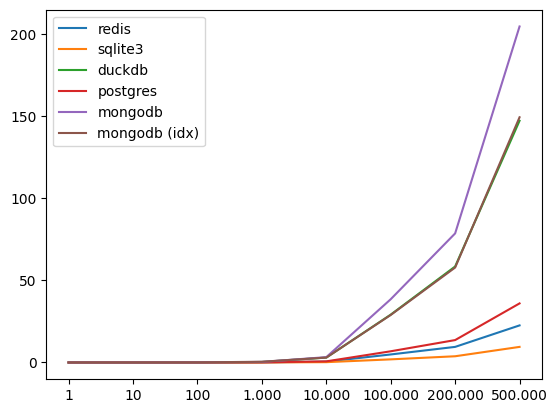

In [21]:
df2=df[(df['db']!='xml') & (df['db']!='lxml')]
cols = [c for c in df2.columns if c != 'db']
categories=[f"{x:,.0f}".replace(',', '.') for x in cols]

for _, row in df2.iterrows():
    plt.plot(categories, row[cols], label=row['db'])

plt.legend()
plt.savefig('../data/plots/performance_no_xml.pdf')
plt.show()

In [22]:
df_init=pd.DataFrame(init_times)
df_init

,db,duration
0,xml,0.006918
1,lxml,0.006918
2,redis,0.075027
3,sqlite3,0.173906
4,duckdb,14.575025
5,postgres,4.211996
6,mongodb,0.149585
7,mongodb (idx),0.135385


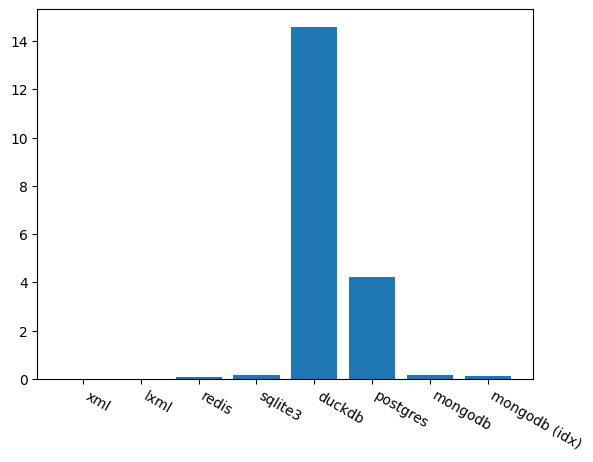

In [23]:
plt.bar(df_init['db'], df_init['duration'], label=row['db'])
plt.xticks(rotation=330,ha='left')
plt.savefig('../data/plots/init_all.pdf')
plt.show()

In [24]:
# save the dataframe for later usage
# only uncomment the next three lines if you REALLY want to override all saved data
#df.to_pickle("../data/df.pickle")
#df_init.to_pickle("../data/df_init.pickle")
#df_backup=df
#last_updated=datetime.now()
print(f"Saved last at: {last_updated}")

Saved last at: 2026-05-14 12:51:12.862147


In [25]:
print(f"Done at: {datetime.now()} with {fake_k} fake records.")

Done at: 2026-05-14 12:51:12.929602 with 100000 fake records.
